Dog
Sample rate: 22050
Sound
Wave sample rate: 44100
Wave audio: [[-6520  4847]
 [-5573  3405]
 [-4430  1540]
 ...
 [ -335  1809]
 [ 3780  4841]
 [ 8293  7039]]
Data: [-0.02002473 -0.04642837 -0.0703963  ... -0.22773516 -0.07861616
  0.15060043]


class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
engine_idling       1000
jackhammer          1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64

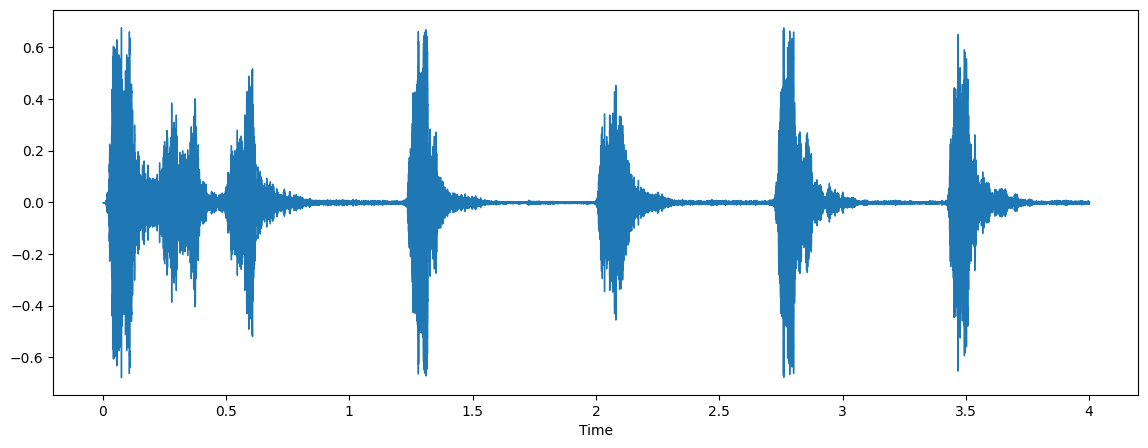

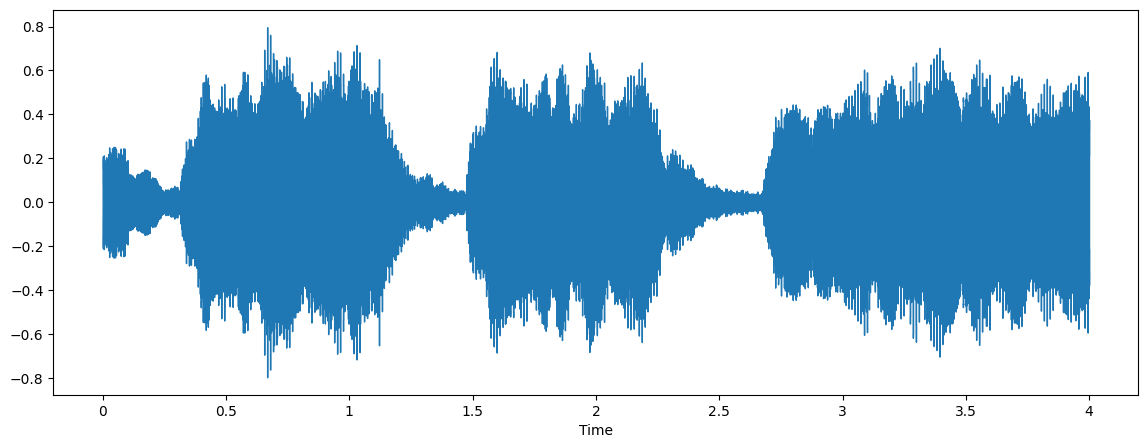

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
### Let's read a sample audio using librosa
import IPython.display as ipd
import librosa
import librosa.display


## Dog sound
filename='UrbanSound8K/dog_bark.wav'
print("Dog")
plt.figure(figsize=(14,5))
data,sample_rate=librosa.load(filename)
librosa.display.waveshow(data,sr=sample_rate)
ipd.Audio(filename)

print("Sample rate:",sample_rate)

print("Sound")
### Sound
filename='UrbanSound8K/carhorn.wav'
plt.figure(figsize=(14,5))
data,sample_rate=librosa.load(filename)
librosa.display.waveshow(data,sr=sample_rate)
ipd.Audio(filename)


### Let's read a sample audio using scipy
from scipy.io import wavfile as wav
wave_sample_rate, wave_audio=wav.read(filename)
print("Wave sample rate:",wave_sample_rate)
print("Wave audio:",wave_audio)
print("Data:",data)


import pandas as pd

metadata=pd.read_csv('UrbanSound8K/metadata/UrbanSound8K.csv')
metadata.head(10)

### Check whether the dataset is imbalanced
metadata['class'].value_counts()

In [5]:
!pip install librosa
!pip install resampy

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


## Data Preprocessing
1.Here Librosa converts the signal to mono, meaning the channel will always be 1.

2.Mel-Frequency Cepstral Coefficients(MFCC) from the audio samples. The MFCC summarises the frequency distribution across the window size, so it is possible to analyse both the frequency and time characteristics of the sound. These audio representations will allow us to identify features for classification.



[-0.02002473 -0.04642837 -0.0703963  ... -0.22773516 -0.07861616
  0.15060043]


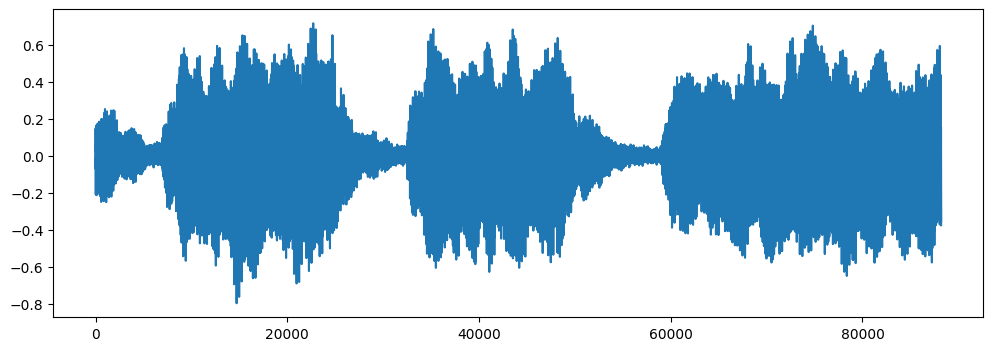

In [8]:
### Let's read a sample audio using librosa
import librosa
audio_file_path='UrbanSound8K/carhorn.wav'
librosa_audio_data,librosa_sample_rate=librosa.load(audio_file_path)
print(librosa_audio_data)

### Lets plot the librosa audio data
import matplotlib.pyplot as plt
# Original audio with 1 channel 
plt.figure(figsize=(12, 4))
plt.plot(librosa_audio_data)

[[-6520  4847]
 [-5573  3405]
 [-4430  1540]
 ...
 [ -335  1809]
 [ 3780  4841]
 [ 8293  7039]]


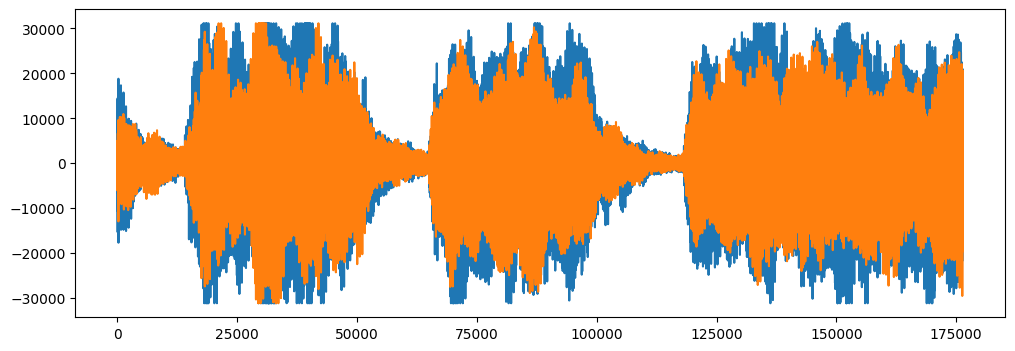

In [9]:
### Lets read with scipy
from scipy.io import wavfile as wav
wave_sample_rate, wave_audio = wav.read(audio_file_path) 
print(wave_audio)

import matplotlib.pyplot as plt

# Original audio with 2 channels 
plt.figure(figsize=(12, 4))
plt.plot(wave_audio)

In [10]:
mfccs = librosa.feature.mfcc(y=librosa_audio_data, sr=librosa_sample_rate, n_mfcc=40)
print("MFCCS shape:",mfccs.shape)

# Extracting MFCC's For every audio file
import pandas as pd
import numpy as np
import os
import librosa

audio_dataset_path='UrbanSound8K/audio/'
metadata=pd.read_csv('UrbanSound8K/metadata/UrbanSound8K.csv')
print(metadata.head())

def features_extractor(file):
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
    return mfccs_scaled_features

from tqdm import tqdm
### Now we iterate through every audio file and extract features 
### using Mel-Frequency Cepstral Coefficients
extracted_features=[]
for index_num,row in tqdm(metadata.iterrows()):
    file_name = os.path.join(os.path.abspath(audio_dataset_path),'fold'+str(row["fold"])+'/',str(row["slice_file_name"]))
    final_class_labels=row["class"]
    data=features_extractor(file_name)
    extracted_features.append([data,final_class_labels])

# converting extracted_features to Pandas dataframe
print("Extracted features to DataFrame:")
extracted_features_df=pd.DataFrame(extracted_features,columns=['feature','class'])
print(extracted_features_df.head())

# Split the dataset into independent and dependent dataset
X=np.array(extracted_features_df['feature'].tolist())
y=np.array(extracted_features_df['class'].tolist())

print("X shape:",X.shape)

# Label Encoding
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()
y=to_categorical(labelencoder.fit_transform(y))

print("y shape:",y.shape)

# Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

print("X train:",X_train.shape)

print("X test:",X_test.shape)
print("y train:",y_train.shape)
print("y test:",y_test.shape)

MFCCS shape: (40, 173)
      slice_file_name    fsID  start        end  salience  fold  classID  \
0    100032-3-0-0.wav  100032    0.0   0.317551         1     5        3   
1  100263-2-0-117.wav  100263   58.5  62.500000         1     5        2   
2  100263-2-0-121.wav  100263   60.5  64.500000         1     5        2   
3  100263-2-0-126.wav  100263   63.0  67.000000         1     5        2   
4  100263-2-0-137.wav  100263   68.5  72.500000         1     5        2   

              class  
0          dog_bark  
1  children_playing  
2  children_playing  
3  children_playing  
4  children_playing  


3554it [04:39, 13.60it/s]/home/rgukt/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
8324it [11:04, 14.62it/s]/home/rgukt/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
8328it [11:04, 19.74it/s]/home/rgukt/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
8732it [11:39, 12.48it/s]


Extracted features to DataFrame:
                                             feature             class
0  [-217.35526, 70.22339, -130.38527, -53.282898,...          dog_bark
1  [-424.09818, 109.34077, -52.919525, 60.86475, ...  children_playing
2  [-458.79114, 121.38419, -46.520657, 52.00812, ...  children_playing
3  [-413.89984, 101.66371, -35.42945, 53.036354, ...  children_playing
4  [-446.60352, 113.68541, -52.402214, 60.302044,...  children_playing
X shape: (8732, 40)


2025-01-01 22:12:40.800015: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-01 22:12:41.318863: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-01 22:12:41.476768: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-01 22:12:42.638211: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-01 22:12:50.234998: W tensorflow/compiler/tf2

y shape: (8732, 10)
X train: (6985, 40)


NameError: name 'rint' is not defined

## model creation

In [1]:
print(y)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten
from tensorflow.keras.optimizers import Adam
from sklearn import metrics

#No of classes
num_labels=y.shape[1]
print(y)

model=Sequential()
#first layer
model.add(Dense(100,input_shape=(40,)))
model.add(Activation('relu'))
model.add(Dropout(0.5))
#second layer
model.add(Dense(200))
model.add(Activation('relu'))
model.add(Dropout(0.5))
#third layer
model.add(Dense(100))
model.add(Activation('relu'))
model.add(Dropout(0.5))

#final layer
model.add(Dense(num_labels))
model.add(Activation('softmax'))

model.summary()

model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='adam')

# Trianing my model
from tensorflow.keras.callbacks import ModelCheckpoint
from datetime import datetime 

num_epochs = 100
num_batch_size = 32
checkpointer = ModelCheckpoint(filepath='saved_models/audio_classification.keras', verbose=1, save_best_only=True)
start = datetime.now()
model.fit(X_train, y_train, batch_size=num_batch_size, epochs=num_epochs, validation_data=(X_test, y_test), callbacks=[checkpointer], verbose=1)


duration = datetime.now() - start
print("Training completed in time: ", duration)
#using function but not working
def features_extractor(filename):
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
    return mfccs_scaled_features
    
filename="UrbanSound8K/dog_bark.wav"

prediction_feature=features_extractor(filename)
prediction_feature=prediction_feature.reshape(1,-1)
 
predicted_label = np.argmax(model.predict(prediction_feature), axis=-1)
print("Predicted label:", predicted_label)

# Map predicted label to class name
prediction_class = labelencoder.inverse_transform(predicted_label)
print("Prediction class:", prediction_class)

model.save("urbansoundmodel.h5")

test_accuracy=model.evaluate(X_test,y_test,verbose=0)
print(test_accuracy[1])


NameError: name 'y' is not defined

In [ ]:
metadata['class'].unique()

In [ ]:
Testing some test data
1.preprocess the new audio data

2.predict the classes

3.invere transform your predicted label

In [ ]:
# Load audio file and extract MFCC features
filename = "UrbanSound8K/carhorn.wav"
audio, sample_rate = librosa.load(filename, res_type='kaiser_fast')
mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
mfccs_scaled_features = np.mean(mfccs_features.T, axis=0)

# Print extracted features
print("MFCCs scaled features:", mfccs_scaled_features)
mfccs_scaled_features = mfccs_scaled_features.reshape(1, -1)
print("MFCCs scaled features (reshaped):", mfccs_scaled_features)
print("MFCCs scaled features shape:", mfccs_scaled_features.shape)

# Predict class
predicted_label = np.argmax(model.predict(mfccs_scaled_features), axis=-1)
print("Predicted label:", predicted_label)

# Map predicted label to class name
prediction_class = labelencoder.inverse_transform(predicted_label)
print("Prediction class:", prediction_class)


In [ ]:
#using function but not working
def features_extractor(filename):
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
    return mfccs_scaled_features
    
filename="UrbanSound8K/dog_bark.wav"

prediction_feature=features_extractor(filename)
prediction_feature=prediction_feature.reshape(1,-1)
 
predicted_label = np.argmax(model.predict(prediction_feature), axis=-1)
print("Predicted label:", predicted_label)

# Map predicted label to class name
prediction_class = labelencoder.inverse_transform(predicted_label)
print("Prediction class:", prediction_class)
